# Final EDA Summary Template

This notebook is a short shared template for final EDA summaries. Each EDA section has only three parts: research question, features/methods, and main findings.

Use the shared `df` loaded below when possible. If a section needs a different CSV, copy the loading cell inside that section and change the path there.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT.name != "summer26-pokemon-battle-predictor" and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"

# Tomorrow, change only this path if everyone is using the same parsed CSV.
PARSED_CSV_PATH = DATA_DIR / "data_cleaned.csv.zip"

print("Project root:", PROJECT_ROOT)
print("Parsed CSV path:", PARSED_CSV_PATH)

Project root: /Users/marznewman/erdoswork/summer26-pokemon-battle-predictor
Parsed CSV path: /Users/marznewman/erdoswork/summer26-pokemon-battle-predictor/data/data_cleaned.csv.zip


In [2]:
# Load the shared dataframe.
# Uncomment after PARSED_CSV_PATH points to the correct file.

df = pd.read_csv(PARSED_CSV_PATH)
print(df.shape)
df.head()

(12778, 299)


,format,id,p1_win,ratedQ,n_turns,start_time,end_time,duration,p1name,p1side,p1elo0,p1elo1,p2name,p2side,p2elo0,p2elo1,type_diversity_diff,num_boosting_abilities_diff,num_move_boosters_diff,total_stat_diff,p1_total_adv,p1_revealed_team_size,p2_revealed_team_size,M11_name,M11_speciesId,M11_used,M11_gender,M11_shinyQ,M11_level,M11_ability,M11_item,M11_teraType,M11_role,M11_mv1,M11_mv2,M11_mv3,M11_mv4,M11_type1,M11_type2,M11_hp,M11_atk,M11_def,M11_spa,M11_spd,M11_spe,M11_off,M12_name,M12_speciesId,M12_used,M12_gender,...,M24_spa,M24_spd,M24_spe,M24_off,M25_name,M25_speciesId,M25_used,M25_gender,M25_shinyQ,M25_level,M25_ability,M25_item,M25_teraType,M25_role,M25_mv1,M25_mv2,M25_mv3,M25_mv4,M25_type1,M25_type2,M25_hp,M25_atk,M25_def,M25_spa,M25_spd,M25_spe,M25_off,M26_name,M26_speciesId,M26_used,M26_gender,M26_shinyQ,M26_level,M26_ability,M26_item,M26_teraType,M26_role,M26_mv1,M26_mv2,M26_mv3,M26_mv4,M26_type1,M26_type2,M26_hp,M26_atk,M26_def,M26_spa,M26_spd,M26_spe,M26_off
0,gen9randombattle,2642076539,0,True,21,1782884765,1782884937,172,Lirnom,1,1624,1607,Jenome,2,1674,1691,0,0,1,-79,3.125322,4,5,Cyclizar,cyclizar,1,M,False,83,Regenerator,Heavy-Duty Boots,Dragon,Fast Support,taunt,rapidspin,shedtail,dracometeor,Dragon,Normal,252,205,156,189,156,249,205,Cramorant,cramorant,1,M,...,182,118,158,198,Tsareena,tsareena,1,F,False,87,Queenly Majesty,Life Orb,Steel,Fast Support,tripleaxel,synthesis,highjumpkick,powerwhip,Grass,NaN,267,259,220,137,220,175,259,Toxtricity,toxtricity,1,F,False,82,Punk Rock,Choice Specs,Normal,Fast Attacker,sludgewave,boomburst,voltswitch,overdrive,Electric,Poison,257,165,162,234,162,170,234
1,gen9randombattle,2642074504,1,True,7,1782884343,1782884385,42,jnpr010334,1,1651,1667,masajji,2,1582,1566,-1,-1,-2,19,0.997149,2,3,Virizion,virizion,1,N,False,82,Justified,Life Orb,Rock,Setup Sweeper,stoneedge,closecombat,swordsdance,leafblade,Grass,Fighting,283,195,165,195,259,224,195,Koraidon,koraidon,0,N,...,199,141,141,250,Gouging Fire,gougingfire,0,N,False,74,Protosynthesis,Heavy-Duty Boots,Fairy,Bulky Setup,heatcrash,morningsun,outrage,dragondance,Fire,Dragon,277,213,222,139,181,178,213,Zangoose,zangoose,1,M,False,85,Toxic Boost,Toxic Orb,Normal,Fast Attacker,knockoff,facade,swordsdance,closecombat,Normal,NaN,263,244,151,151,151,202,244
2,gen9randombattle,2641921866,1,False,31,1782859109,1782859432,323,realgreenz,1,0,0,ABIDTHEBEST,2,0,0,0,0,1,129,5.479100,6,6,Plusle,plusle,1,M,False,95,Lightning Rod,Life Orb,Fairy,Setup Sweeper,thunderbolt,nastyplot,encore,alluringvoice,Electric,NaN,268,100,130,215,196,234,215,Hatterene,hatterene,1,F,...,188,236,219,188,Passimian,passimian,1,M,False,83,Defiant,Leftovers,Steel,Bulky Setup,gunkshot,bulkup,drainpunch,knockoff,Fighting,NaN,302,247,197,114,147,180,247,Tornadus,tornadus,1,M,False,82,Prankster,Heavy-Duty Boots,Flying,Fast Attacker,nastyplot,bleakwindstorm,grassknot,focusblast,Flying,NaN,264,193,162,252,178,229,252
3,gen9randombattle,2641831207,1,True,51,1782847154,1782847410,256,soumatou_story,1,2113,2127,TheLastOne,2,2014,2000,-2,-2,2,347,3.903277,6,6,Tsareena,tsareena,1,F,False,87,Queenly Majesty,Choice Scarf,Steel,Fast Support,tripleaxel,knockoff,powerwhip,uturn,Grass,NaN,267,259,220,137,220,175,259,Snorlax,snorlax,1,F,...,143,179,270,234,Hitmonchan,hitmonchan,1,M,False,87,Iron Fist,Leftovers,Steel,Bulky Support,encore,drainpunch,knockoff,poisonjab,Fighting,NaN,229,232,187,111,241,182,232,Corviknight,corviknight,1,M,False,80,Mirror Armor,Rocky Helmet,Dragon,Bulky Support,uturn,bodypress,bravebird,roost,Flying,Steel,288,185,214,131,182,153,185
4,gen9randombattle,2642210572,1,True,18,1782911409,1782911669,260,jobzy,1,1177,1201,danbur,2,1165,1141,0,2,1,-120,1.475808,2,6,Dewgong,dewgong,1,M,False,94,Thick Fat,Assault Vest,Poison,Bulky Attacker,knockoff,tripleaxel,surf,flipturn,Water,Ice,322,185,204,185,232,185,185,Iron Boulder,ironboulder,0,N,...,152,170,195,256,Jirachi,jirachi,1,N,False,80,Serene Grace,Leftovers,Water,Fast Support,bodyslam,ironhead,protect,wish,Steel,Psychi

See `data/README.md` for a thorough description of the column headers.

## 1. General Pokemon EDA

### Research Question

-

### Features Looking Into And Methods

Focus: General Pokemon stats, types, and team composition.

-

### Main Findings

-

In [3]:
# Optional: create the key summary table or plot for this section.
# Use the shared df, or load a section-specific CSV here if needed.

# summary_table = ...
# summary_table

## 2. First Pokemon Advantage EDA

### Research Question

-

### Features Looking Into And Methods

Focus: Opening Pokemon / first matchup advantage.

-

### Main Findings

-

In [4]:
# Optional: create the key summary table or plot for this section.
# Use the shared df, or load a section-specific CSV here if needed.

# summary_table = ...
# summary_table

## 3. Active Switch Count And Win Rate EDA

### Research Question

- Switching out an active Pokemon essentially forfeits a turn during a Pokemon battle. With this in mind, does a higher switch rate decrease the probability of a win? Does switching in the first turn before making a move affect probability of a win?

### Features Looking Into And Methods

Focus: Relationship between active switches during battle and win rate.


### Main Findings

- Lowest-rated players tend to switch less
- Overall switch rate doesn't significantly affect win rate
- Switching in the first turn is a slight disadvantage

In [5]:
import sys

sys.path.append(str(PROJECT_ROOT / "tools"))
from battle import Battle

# Function for getting stats about player switches
def get_switch_stats(battle):
    '''
    Gets following stats from Pokemon showdown logs:

    - turns
        Number of turns in the battle
    - <player>_switches
        Total number of player switches excluding lead Pokemon and fainting
    - <player>_switched_early
        Flags whether a player swapped their lead Pokemon on turn 1 before making a move
    '''

    # Ignore the first "switch" that is actually just the lead pokemon
    p1_switches = -1
    p2_switches = -1

    p1_seen_move = False
    p2_seen_move = False

    p1_switched_early = 0
    p2_switched_early = 0

    # Flag that says whether the pokemon has fainted and needs replacement
    p1_needs_replacement = False
    p2_needs_replacement = False

    turns = 0

    for line in battle.log.split("\n"):
        #print(line)
        # Trying to ignore switches caused by fainting
        if line.startswith("|faint|"):
            if "|p1" in line:
                p1_needs_replacement = True

            elif "|p2" in line:
                p2_needs_replacement = True

        # increment nummber of turns
        #if line.startswith("|turn|"):
        #    turns = int(line.split("|")[2])

        fields = line.split("|")

        if len(fields) < 3:
            continue

        if line.startswith("|move|"):
            #print(line)

            slot = fields[2]

            if slot.startswith("p1"):
                p1_seen_move = True

            elif slot.startswith("p2"):
                p2_seen_move = True
                
        elif line.startswith("|switch|"):

            slot = fields[2]

            if slot.startswith("p1"):

                if not p1_needs_replacement:
                    p1_switches += 1

                p1_needs_replacement = False

                if not p1_seen_move and p1_switches > 0:
                    p1_switched_early = 1

            elif slot.startswith("p2"):

                if not p2_needs_replacement:
                    p2_switches += 1

                p2_needs_replacement = False

                if not p2_seen_move and p2_switches > 0:
                    p2_switched_early = 1
                    
    return {
        #"turns": turns,
        "p1_switches": p1_switches,
        "p2_switches": p2_switches,
        "p1_switched_early": p1_switched_early,
        "p2_switched_early": p2_switched_early
    }

In [6]:
# Optional: create the key summary table or plot for this section.
# Use the shared df, or load a section-specific CSV here if needed.

# summary_table = ...
# summary_table

# Load in individual replays
replay_root = DATA_DIR / "replays"

replay_dirs = [
    replay_root / "gen9-randombattle",
    replay_root / "gen9-randombattle_2",
    replay_root / "gen9-randombattle_3",
]

files = []
for replay_dir in replay_dirs:
    files.extend(sorted(replay_dir.glob("*.json")))

print(f"There are {len(files)} replay files")
#print(replay_dir)
#print(replay_dir.exists())
#print(len(files))
#print(files)

rows = []

for file in files:

    try:
        battle = Battle(file)
    except Exception:
        continue

    stats = get_switch_stats(battle)
    rows.append({"id": battle.id, **stats})

# Create dataframe with the output of get_switch_stats
switch_df = pd.DataFrame(rows)

# remove string at the beginning of the battle id
switch_df["id"] = (
    switch_df["id"]
    .str.replace("gen9randombattle-", "", regex=False)
    .astype(int)
)

#print(df.columns.tolist())
#print(switch_df.columns.tolist())
#print(switch_df.head())
#print(switch_df.columns)
#print(df["id"].head())
#print(switch_df["id"].head())

# Ignore unranked matches
ranked_df = df[df["p1elo0"] > 0]
print(len(df))
print(len(ranked_df))

# Merge main dataframe with switched stats dataframe
merged_df = ranked_df.merge(switch_df, on="id", how="left")
print(len(merged_df))
#merged_df = merged_df[merged_df["p1elo0"] > 0]
#print(len(merged_df))

#print(df.shape)

There are 12778 replay files
12778
12381
12381


24762


Text(0.5, 1.0, 'Early Switching vs Win Rate')

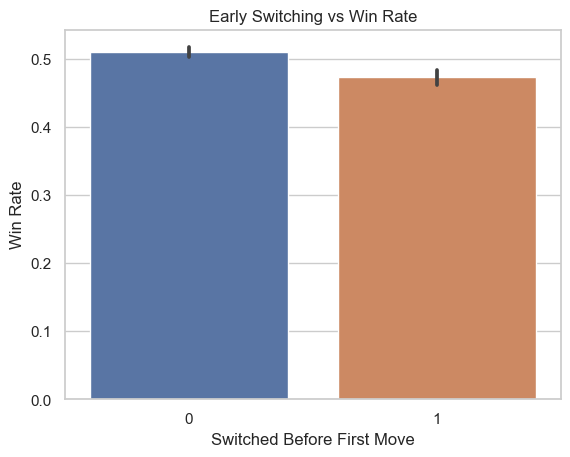

In [7]:
# Early switching versus win rate
# Look at all players regardless of battle id
early_df = pd.DataFrame({
    "switched_early": pd.concat([
        merged_df["p1_switched_early"],
        merged_df["p2_switched_early"]
    ]),
    "won": pd.concat([
        merged_df["p1_win"],
        1 - merged_df["p1_win"]
    ])
})

print(len(early_df))
sns.barplot(data=early_df, x="switched_early", y="won")

plt.xlabel("Switched Before First Move")
plt.ylabel("Win Rate")
plt.title("Early Switching vs Win Rate")

Switched Before First Move
  -  0 if False
  -  1 if True

The win rate is a bit above 0.5 if the player did not switch before the first move. This is a slightly higher win rate than players who did switch before the first move, suggesting that forfeiting the first turn by swapping the lead Pokemon may be a disadvantage. 

On the other hand, experienced players may recognize a disadvantage (either in Pokemon type, species, or some other stats-based disadvantage) in their first matchup and switch out the lead Pokemon in response to the disadvantage, meaning that this pattern is more about correlation than causation.

/opt/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


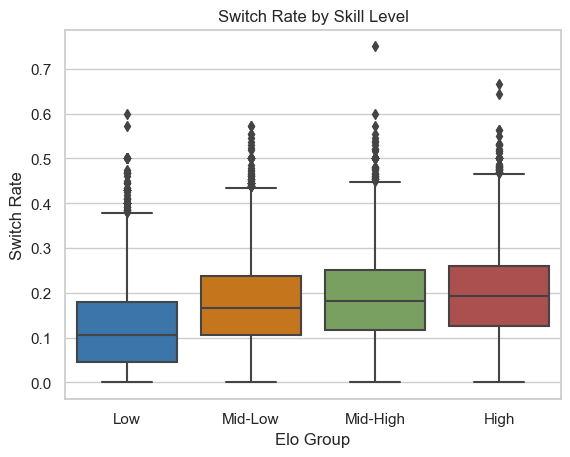

In [14]:
# Switching by elo
# create a dataframe with each player having their own row
player_df = pd.DataFrame({

    "elo": pd.concat([
        merged_df["p1elo0"],
        merged_df["p2elo0"]
    ]),

    "switches": pd.concat([
        merged_df["p1_switches"],
        merged_df["p2_switches"]
    ]),

    "turns": pd.concat([
        merged_df["n_turns"],
        merged_df["n_turns"]
    ]),

    "switch_rate": pd.concat([
        merged_df["p1_switches"] / merged_df["n_turns"],
        merged_df["p2_switches"] / merged_df["n_turns"]
    ]),

    "won": pd.concat([
        merged_df["p1_win"],
        1 - merged_df["p1_win"]
    ])
})

#print(player_df)

# separate elo score groups into 4 different bins
player_df["elo_group"] = pd.qcut(
    player_df["elo"],
    q=4,
    labels=["Low", "Mid-Low", "Mid-High", "High"]
)

# Total number of switches by elo score 
#sns.boxplot(data=player_df, x="elo_group", y="switches")

#plt.xlabel("Elo Group")
#plt.ylabel("Number of Switches")
#plt.title("Switching Frequency by Skill Level")
#plt.show()

# Switch rate by elo
boxplot_colors = ["#2976bb", "#e17701", "#77ab56", "#bb3f3f"]
sns.boxplot(data=player_df, x="elo_group", y="switch_rate", palette=boxplot_colors)

plt.xlabel("Elo Group")
plt.ylabel("Switch Rate")
plt.title("Switch Rate by Skill Level")
plt.show()

switch_rate = $\frac{total\ number\ of\ player\ switches}{number\ of\ turns}$

Elo score is a way of quantifying a player's skill level. It can be assumed that players with a higher elo score would therefore have a better intuition for when it is advantageous to swap their Pokemon and may be a more reliable predictor of win rate.

The above box plot shows that the lowest-rated players swap their Pokemon noticably less than other players. The switch rate appears to level off starting with mid-high elo scores. 

Text(0.5, 1.0, 'Win Rate vs Switch Rate')

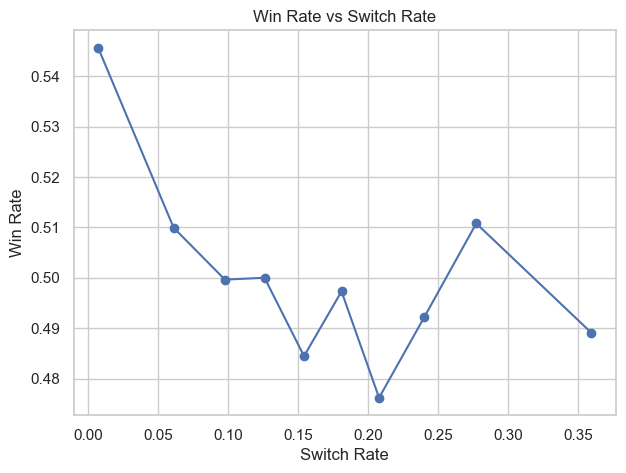

In [9]:
# Win rate versus switch rate
# Bin switch_rate into groups for plotting
player_df["switch_bin"] = pd.qcut(player_df["switch_rate"], 10, duplicates="drop")

summary = (
    player_df
    .groupby("switch_bin", observed=True)
    .agg(
        mean_switch=("switch_rate", "mean"),
        win_rate=("won", "mean")
    )
    .reset_index()
)

plt.figure(figsize=(7,5))

plt.plot(
    summary["mean_switch"],
    summary["win_rate"],
    marker="o"
)

plt.xlabel("Switch Rate")
plt.ylabel("Win Rate")
plt.title("Win Rate vs Switch Rate")

switch_rate = $\frac{total\ number\ of\ player\ switches}{number\ of\ turns}$

Each point represents a group with similar switch rates. The trend begins with win rate decreasing as switch rate increases, which agrees with the first plot showing that early switching might lead to lower win rate. Once we get to switch_rate > 0.10, however, there is a large scatter that contrasts the initial appearance of a downward trend.

## 4. Pokemon Advantage Stats EDA

### Research Question

-

### Features Looking Into And Methods

Focus: Pokemon advantage features and their relation to battle outcome.

-

### Main Findings

-

In [10]:
# Optional: create the key summary table or plot for this section.
# Use the shared df, or load a section-specific CSV here if needed.

# summary_table = ...
# summary_table

# Overall Takeaways

### Research Question

What did the combined EDA work help us understand about Pokemon battle prediction?

-

### Features Looking Into And Methods

-

### Main Findings

-